In [1]:
!pip install -q ultralytics

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.1/46.1 kB 1.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 21.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.2/53.2 kB 2.0 MB/s eta 0:00:00


In [2]:
from pathlib import Path
import zipfile
import yaml
import cv2
import matplotlib.pyplot as plt
import ultralytics
from ultralytics import YOLO

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [3]:
from google.colab import drive

drive.mount("/content/drive")

Mounted at /content/drive


In [4]:
ZIP_PATH = "/content/drive/MyDrive/Smart_Warehouse_Inventory_Project.zip"

EXTRACT_PATH = "/content"

with zipfile.ZipFile(ZIP_PATH, "r") as zip_ref:
    zip_ref.extractall(EXTRACT_PATH)

print("Project extracted successfully!")

Project extracted successfully!


In [5]:
import os

print(os.listdir("/content"))

['.config', 'drive', 'Smart_Warehouse_Inventory_Project', 'sample_data']


In [6]:
from pathlib import Path

PROJECT_ROOT = Path("/content/Smart_Warehouse_Inventory_Project")

DATASET_PATH = PROJECT_ROOT / "dataset"

TRAIN_IMAGES = DATASET_PATH / "images" / "train"
VALID_IMAGES = DATASET_PATH / "images" / "val"
TEST_IMAGES = DATASET_PATH / "images" / "test"

DATA_YAML = DATASET_PATH / "data.yaml"

MODEL_PATH = Path(
    "/content/drive/MyDrive/YOLO_Training_imgsz640/warehouse_inventory_100epochs/weights/best_100epochs.pt"
)

OUTPUT_PATH = PROJECT_ROOT / "output" / "predictions"
OUTPUT_PATH.mkdir(parents=True, exist_ok=True)

In [7]:
print("Project Exists :", PROJECT_ROOT.exists())
print("Dataset Exists :", DATASET_PATH.exists())
print("Data YAML Exists :", DATA_YAML.exists())
print("Model Exists :", MODEL_PATH.exists())
print("Test Images Exists :", TEST_IMAGES.exists())
print("Output Exists :", OUTPUT_PATH.exists())

Project Exists : True
Dataset Exists : True
Data YAML Exists : True
Model Exists : True
Test Images Exists : True
Output Exists : True


In [8]:
# Read data.yaml file

with open(DATA_YAML, "r") as file:
    data = yaml.safe_load(file)
print(f"Train Path      : {data['train']}")
print(f"Validation Path : {data['val']}")
print(f"Test Path       : {data['test']}")
print(f"Number of Classes : {data['nc']}")

print("\nCLASS NAMES")
print("-" * 60)

for class_id, class_name in data["names"].items():
    print(f"{class_id:2} --> {class_name}")

Train Path      : images/train
Validation Path : images/val
Test Path       : images/test
Number of Classes : 25

CLASS NAMES
------------------------------------------------------------
 0 --> box
 1 --> crate
 2 --> barrel
 3 --> bottle
 4 --> pallet
 5 --> rack
 6 --> bracket
 7 --> lamp
 8 --> sign
 9 --> wire
10 --> fuse_box
11 --> floor_decal
12 --> fire_extinguisher
13 --> barcode
14 --> wall
15 --> ceiling
16 --> floor
17 --> pillar
18 --> forklift
19 --> bucket
20 --> cone
21 --> cart
22 --> emergency_board
23 --> paper_note
24 --> paper_shortcut


In [9]:

# LOAD TRAINED MODEL
model = YOLO(MODEL_PATH)

print("Model loaded successfully!")

Model loaded successfully!


In [10]:


print("Model Type :", type(model))
print("\nClass Names:")

for class_id, class_name in model.names.items():
    print(f"{class_id:2} --> {class_name}")

Model Type : <class 'ultralytics.models.yolo.model.YOLO'>

Class Names:
 0 --> box
 1 --> crate
 2 --> barrel
 3 --> bottle
 4 --> pallet
 5 --> rack
 6 --> bracket
 7 --> lamp
 8 --> sign
 9 --> wire
10 --> fuse_box
11 --> floor_decal
12 --> fire_extinguisher
13 --> barcode
14 --> wall
15 --> ceiling
16 --> floor
17 --> pillar
18 --> forklift
19 --> bucket
20 --> cone
21 --> cart
22 --> emergency_board
23 --> paper_note
24 --> paper_shortcut


In [11]:

# SELECT A TEST IMAGE

test_images = sorted(TEST_IMAGES.glob("*"))

print(f"Total Test Images : {len(test_images)}")

image_path = test_images[0]

print("\nSelected Image:")
print(image_path)

Total Test Images : 1124

Selected Image:
/content/Smart_Warehouse_Inventory_Project/dataset/images/test/warehouse_000001.png


In [12]:
# READ IMAGE

image = cv2.imread(str(image_path))
print("Image Loaded Successfully")
print("Image Shape :", image.shape)

Image Loaded Successfully
Image Shape : (512, 512, 3)


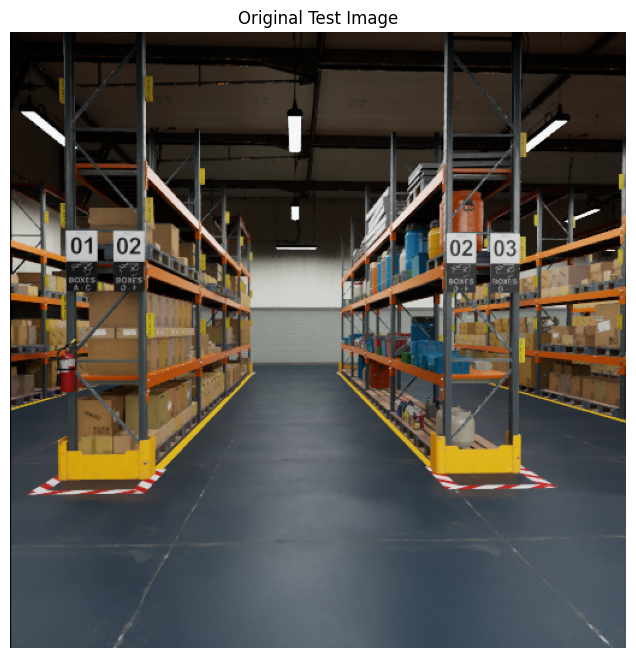

In [13]:

# DISPLAY ORIGINAL IMAGE


image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(8,8))

plt.imshow(image_rgb)

plt.title("Original Test Image")

plt.axis("off")

plt.show()

In [14]:

# RUN PREDICTION

results = model.predict(

    source=str(image_path),

    conf=0.25,

    save=False,

    verbose=False

)

print("Prediction Completed Successfully!")

Prediction Completed Successfully!


In [15]:
# UNDERSTAND PREDICTION OUTPUT


print(type(results))

print("Number of Results :", len(results))

<class 'list'>
Number of Results : 1


In [16]:
result = results[0]

print(type(result))

<class 'ultralytics.engine.results.Results'>


In [17]:

# EXTRACT ALL DETECTED BOUNDING BOXES

boxes = result.boxes

print(type(boxes))
print("Total Objects Detected :", len(boxes))

<class 'ultralytics.engine.results.Boxes'>
Total Objects Detected : 19


In [18]:
# ==========================================================
# DRAW BOUNDING BOXES MANUALLY
# ==========================================================

predicted_image = image.copy()

for box in boxes:

    # Bounding box coordinates
    x1, y1, x2, y2 = map(int, box.xyxy[0])

    # Class ID
    class_id = int(box.cls)

    # Confidence
    confidence = float(box.conf)

    # Class name
    class_name = model.names[class_id]

    # Label
    label = f"{class_name} {confidence:.2f}"

    # Draw rectangle
    cv2.rectangle(
        predicted_image,
        (x1, y1),
        (x2, y2),
        (0, 255, 0),
        2
    )

    # Draw label
    cv2.putText(
        predicted_image,
        label,
        (x1, y1 - 10),
        cv2.FONT_HERSHEY_SIMPLEX,
        0.5,
        (255, 0, 0),
        2
    )

print("Bounding boxes drawn successfully!")

Bounding boxes drawn successfully!


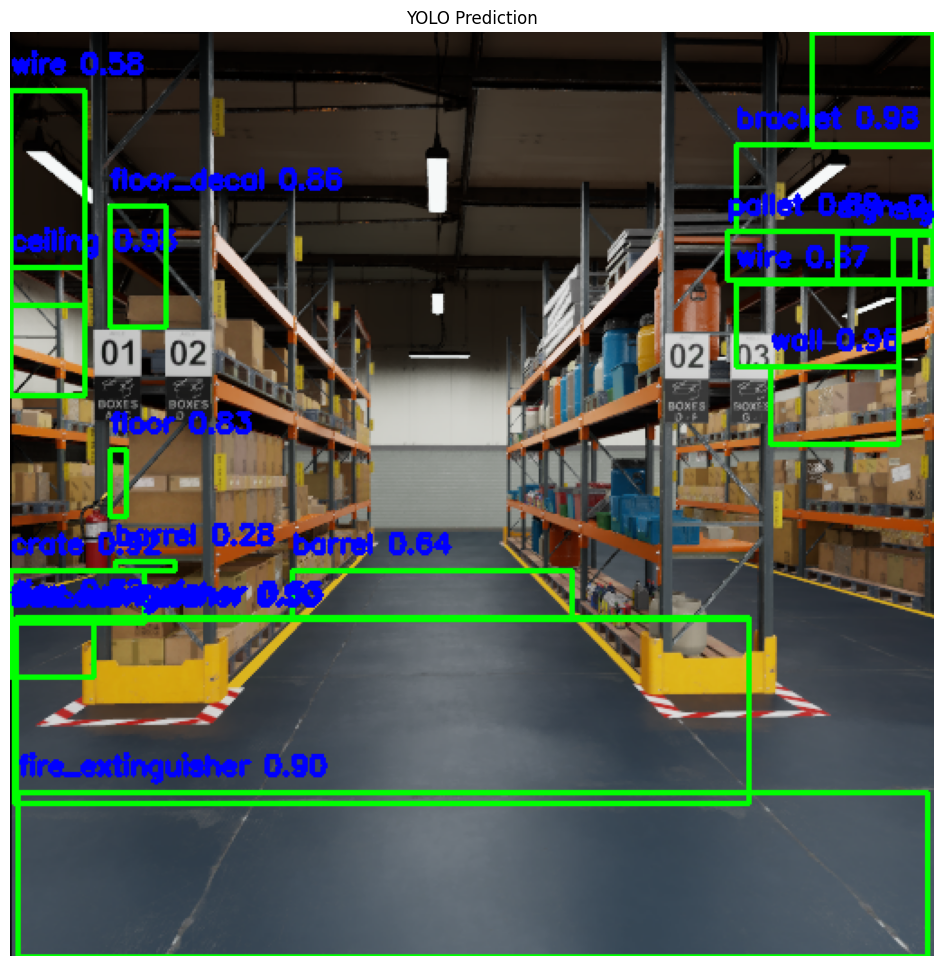

In [19]:
# ==========================================================
# DISPLAY PREDICTION
# ==========================================================

predicted_rgb = cv2.cvtColor(
    predicted_image,
    cv2.COLOR_BGR2RGB
)

plt.figure(figsize=(12,12))

plt.imshow(predicted_rgb)

plt.title("YOLO Prediction")

plt.axis("off")

plt.show()

In [20]:
# ==========================================================
# SAVE PREDICTION
# ==========================================================

output_file = OUTPUT_PATH / "prediction_result_100epochs.jpg"

cv2.imwrite(
    str(output_file),
    predicted_image
)

print("Prediction saved successfully!")

print(output_file)

Prediction saved successfully!
/content/Smart_Warehouse_Inventory_Project/output/predictions/prediction_result_100epochs.jpg


In [21]:
# ==========================================================
# BATCH PREDICTION
# ==========================================================

results = model.predict(
    source=str(TEST_IMAGES),
    conf=0.25,
    save=True,
    project=str(OUTPUT_PATH),
    name="batch_predictions_100epochs",
    exist_ok=True,
    verbose=True
)

print("Batch prediction completed successfully!")


WARNING ⚠️ 
Inference results will accumulate in RAM unless `stream=True` is passed, which can cause out-of-memory errors for large
sources or long-running streams and videos. See https://docs.ultralytics.com/modes/predict/ for help.

Example:
    results = model(source=..., stream=True)  # generator of Results objects
    for r in results:
        boxes = r.boxes  # Boxes object for bbox outputs
        masks = r.masks  # Masks object for segment masks outputs
        probs = r.probs  # Class probabilities for classification outputs

image 1/1124 /content/Smart_Warehouse_Inventory_Project/dataset/images/test/warehouse_000001.png: 640x640 1 box, 1 crate, 2 barrels, 1 pallet, 1 bracket, 2 signs, 2 wires, 1 floor_decal, 3 fire_extinguishers, 1 barcode, 1 wall, 1 ceiling, 1 floor, 1 pillar, 283.2ms
image 2/1124 /content/Smart_Warehouse_Inventory_Project/dataset/images/test/warehouse_000003.png: 640x640 1 box, 1 crate, 2 barrels, 2 pallets, 1 bracket, 2 signs, 2 wires, 1 floor_decal, 3 fi

In [22]:
prediction_folder = OUTPUT_PATH / "batch_predictions_100epochs"

print("Prediction Folder Exists :", prediction_folder.exists())

print("\nSample Files:")

prediction_files = sorted(prediction_folder.glob("*"))

for file in prediction_files[:10]:
    print(file.name)

Prediction Folder Exists : True

Sample Files:
warehouse_000001.jpg
warehouse_000003.jpg
warehouse_000004.jpg
warehouse_000006.jpg
warehouse_000013.jpg
warehouse_000015.jpg
warehouse_000017.jpg
warehouse_000026.jpg
warehouse_000029.jpg
warehouse_000045.jpg


In [23]:
total_predictions = len(list(prediction_folder.glob("*")))

print("=" * 50)

print("Total Prediction Images :", total_predictions)

print("=" * 50)

Total Prediction Images : 1124


In [24]:
# ==========================================================
# FIND LABEL FILE FOR THE CURRENT IMAGE
# ==========================================================

label_path = (
    PROJECT_ROOT /
    "dataset" /
    "labels" /
    "test" /
    f"{image_path.stem}.txt"
)

print(label_path)
print("Exists :", label_path.exists())
# ==========================================================
# READ GROUND TRUTH LABELS
# ==========================================================

with open(label_path, "r") as file:
    ground_truth = file.readlines()

print("Ground Truth Objects :", len(ground_truth))
prediction_count = len(boxes)

print("Predicted Objects :", prediction_count)
print("=" * 60)
print("GROUND TRUTH vs MODEL PREDICTION")
print("=" * 60)

print(f"Image                : {image_path.name}")
print(f"Ground Truth Objects : {len(ground_truth)}")
print(f"Predicted Objects    : {prediction_count}")
print(f"Difference           : {prediction_count - len(ground_truth)}")

/content/Smart_Warehouse_Inventory_Project/dataset/labels/test/warehouse_000001.txt
Exists : True
Ground Truth Objects : 18
Predicted Objects : 19
GROUND TRUTH vs MODEL PREDICTION
Image                : warehouse_000001.png
Ground Truth Objects : 18
Predicted Objects    : 19
Difference           : 1


In [25]:
import shutil
from pathlib import Path

source = OUTPUT_PATH / "prediction_result_100epochs.jpg"
destination = Path("/content/drive/MyDrive/YOLO_Training_imgsz640")

if source.exists():
    shutil.copy(source, destination)
    print("Prediction image saved to Google Drive.")
else:
    print("Prediction image not found.")

Prediction image saved to Google Drive.


In [26]:
import shutil
from pathlib import Path

source = OUTPUT_PATH / "batch_predictions_100epochs"
destination = Path("/content/drive/MyDrive/YOLO_Training_imgsz640/batch_predictions_100epochs")

if source.exists():
    shutil.copytree(source, destination, dirs_exist_ok=True)
    print("Batch predictions saved.")
else:
    print("Batch prediction folder not found.")

Batch predictions saved.
